# Yelp Review Prediction

This notebook studies a simple question:

**Can a business's Yelp reviews in its first 30 days predict its average rating over the rest of its first year?**

The workflow is:

1. Load the cleaned Yelp business and review data
2. Use the full dataset and define the chosen cohort year
3. Define an **early** window and a **future** window
4. Aggregate review-level data into **one row per business**
5. Train regression models
6. Compare results and interpret what matters most

## 1. Project configuration

All key choices are stored as constants below so they can be changed later for robustness checks.
For example, you can change the cohort year or window sizes without rewriting the notebook.

This version uses the **full cleaned dataset** rather than filtering to one location.


In [ ]:
# =========================
# Project configuration
# =========================

COHORT_YEAR = 2015

# Early window: first 30 days after the business's first review
EARLY_WINDOW_DAYS = 30

# Future window: day 31 through day 365 after the business's first review
FUTURE_WINDOW_START_DAY = EARLY_WINDOW_DAYS + 1
FUTURE_WINDOW_END_DAY = 365 * 3

# Minimum review thresholds to keep a business in the final modeling dataset
MIN_EARLY_REVIEWS = 2
MIN_FUTURE_REVIEWS = 3

## 2. Load the cleaned Yelp data

This version of the notebook uses the cleaned CSV files created in the preprocessing step.
These files already keep only the columns needed for the project.

We load:

- `business_clean.csv`
- `review_clean.csv`

and then convert the review date column back to datetime.

In [21]:
import pandas as pd

# Load the cleaned Yelp CSV files
business_df = pd.read_csv("processed_data/business_clean.csv")
review_df = pd.read_csv("processed_data/review_clean.csv")

# Convert review date from string to datetime
review_df["date"] = pd.to_datetime(review_df["date"])

print("Business shape:", business_df.shape)
print("Review shape:", review_df.shape)

business_df.head()

Business shape: (119698, 4)
Review shape: (5791236, 6)


,business_id,review_count,stars,categories
0,mpf3x-BjTdTEA3yCZrAYPw,15,3.0,"Shipping Centers, Local Services, Notaries, Ma..."
1,MTSW4McQd7CbVtyjqoe9mw,80,4.0,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
2,mWMc6_wTdE0EUBKIGXDVfA,13,4.5,"Brewpubs, Breweries, Food"
3,CF33F8-E6oudUQ46HnavjQ,6,2.0,"Burgers, Fast Food, Sandwiches, Food, Ice Crea..."
4,n_0UpQx1hsNbnPUSlodU8w,13,2.5,"Sporting Goods, Fashion, Shoe Stores, Shopping..."


## 4. Define the business cohort

For each business, we find the date of its **first review**.
We then keep only businesses whose first review occurred in the selected cohort year.

This first review date becomes the business's time zero, or **t0**.

In [22]:
# Find the first review date for each business in the full dataset
first_review_df = (
    review_df.groupby("business_id", as_index=False)["date"]
    .min()
    .rename(columns={"date": "first_review_date"})
)

# Keep only businesses whose first review date is in the chosen cohort year
cohort_business_df = first_review_df[
    first_review_df["first_review_date"].dt.year == COHORT_YEAR
].copy()

# Filter both the business table and the review table to this cohort
business_cohort_df = business_df[
    business_df["business_id"].isin(cohort_business_df["business_id"])
].copy()

review_cohort_df = review_df[
    review_df["business_id"].isin(cohort_business_df["business_id"])
].copy()

print("Cohort businesses:", business_cohort_df.shape)
print("Cohort reviews:", review_cohort_df.shape)


Cohort businesses: (11643, 4)
Cohort reviews: (393725, 6)


## 5. Label reviews as early, future, or outside the study window

For each review, we compute how many days it occurred after the business's first review.

Window definitions:

- **early**: day 0 through day 30
- **future**: day 31 through day 365
- **other**: anything outside those windows

Later, we will keep only the `early` and `future` reviews for analysis.


In [23]:
# Attach each business's first review date to every review in the cohort
review_cohort_df = review_cohort_df.merge(
    cohort_business_df,
    on="business_id",
    how="left"
)

# Compute the number of days since the business's first review
review_cohort_df["days_since_first_review"] = (
    review_cohort_df["date"] - review_cohort_df["first_review_date"]
).dt.days

# Initialize all reviews as "other"
review_cohort_df["window"] = "other"

# Label early reviews
review_cohort_df.loc[
    review_cohort_df["days_since_first_review"].between(0, EARLY_WINDOW_DAYS),
    "window"
] = "early"

# Label future reviews
review_cohort_df.loc[
    review_cohort_df["days_since_first_review"].between(
        FUTURE_WINDOW_START_DAY,
        FUTURE_WINDOW_END_DAY
    ),
    "window"
] = "future"

print(review_cohort_df["window"].value_counts())


window
other     236704
future    134574
early      22447
Name: count, dtype: int64


## 6. Build the business-level modeling table

The raw Yelp data is review-level, but the model should work at the **business level**.

So we create **one row per business**.

### Early-window features
- `early_review_count`: number of early reviews
- `early_avg_rating`: average early star rating
- `early_rating_std`: variability in early ratings
- `early_avg_review_length`: average number of words in early reviews

### Future target
- `future_review_count`: number of future reviews
- `future_avg_rating`: average future star rating
- `future_avg_review_length`: average number of words in future reviews

In [24]:
# Keep only reviews that are actually part of the study windows
analysis_reviews_df = review_cohort_df[
    review_cohort_df["window"].isin(["early", "future"])
].copy()

# Split into early and future subsets
early_reviews_df = analysis_reviews_df[
    analysis_reviews_df["window"] == "early"
].copy()

future_reviews_df = analysis_reviews_df[
    analysis_reviews_df["window"] == "future"
].copy()

# Sort reviews by business and date
early_reviews_df = early_reviews_df.sort_values(["business_id", "date"]).copy()
future_reviews_df = future_reviews_df.sort_values(["business_id", "date"]).copy()

# Create review length as number of words in each review
early_reviews_df["review_length"] = (
    early_reviews_df["text"].fillna("").str.split().str.len()
)

future_reviews_df["review_length"] = (
    future_reviews_df["text"].fillna("").str.split().str.len()
)

# Aggregate early-window review information to one row per business
early_features_df = (
    early_reviews_df.groupby("business_id")
    .agg(
        early_review_count=("review_id", "count"),
        early_avg_rating=("stars", "mean"),
        early_rating_std=("stars", "std"),
        early_avg_review_length=("review_length", "mean")
    )
    .reset_index()
)

# Aggregate future-window review information to one row per business
future_target_df = (
    future_reviews_df.groupby("business_id")
    .agg(
        future_review_count=("review_id", "count"),
        future_avg_rating=("stars", "mean"),
        future_avg_review_length=("review_length", "mean")
    )
    .reset_index()
)

# Merge predictors and target
model_df = early_features_df.merge(
    future_target_df,
    on="business_id",
    how="inner"
)

# If a business has only one early review, the std is NaN
# Fill it with 0 because there is no variation with one value
model_df["early_rating_std"] = model_df["early_rating_std"].fillna(0)

# Keep only businesses with enough reviews in both windows
model_df = model_df[
    (model_df["early_review_count"] >= MIN_EARLY_REVIEWS) &
    (model_df["future_review_count"] >= MIN_FUTURE_REVIEWS)
].copy()

print("Final modeling dataset shape:", model_df.shape)
model_df.head()

Final modeling dataset shape: (2302, 8)


,business_id,early_review_count,early_avg_rating,early_rating_std,early_avg_review_length,future_review_count,future_avg_rating,future_avg_review_length
0,--9osgUCSDUWUkoTLdvYhQ,3,5.00,0.000000,158.666667,8,4.750000,99.500000
4,-0iIxySkp97WNlwK66OGWg,10,4.60,0.966092,92.000000,92,3.717391,98.271739
6,-16EH6b1ho0xQqP0Bzm9Mg,2,5.00,0.000000,133.000000,12,4.166667,70.166667
8,-1XSzguS6XLN-V6MVZMg2A,10,4.90,0.316228,92.000000,246,4.662602,118.756098
20,-78Va3llKcPbL6SW4is8lw,4,4.25,0.957427,89.000000,35,3.628571,94.200000


## 7. Quick sanity checks

Before modeling, it is helpful to check:

- the size of the final dataset
- summary statistics
- missing values
- whether the target distribution looks reasonable
- whether early average rating appears related to future average rating


In [25]:
import matplotlib.pyplot as plt

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

Model dataset shape: (2302, 8)

Columns:
['business_id', 'early_review_count', 'early_avg_rating', 'early_rating_std', 'early_avg_review_length', 'future_review_count', 'future_avg_rating', 'future_avg_review_length']

Summary statistics:
       early_review_count  early_avg_rating  early_rating_std  \
count         2302.000000       2302.000000       2302.000000   
mean             5.355343          3.991958          0.750091   
std              7.096079          1.128196          0.809636   
min              2.000000          1.000000          0.000000   
25%              2.000000          3.400000          0.000000   
50%              3.000000          4.400000          0.577350   
75%              5.000000          5.000000          1.290310   
max             68.000000          5.000000          2.828427   

       early_avg_review_length  future_review_count  future_avg_rating  \
count              2302.000000          2302.000000        2302.000000   
mean                116.068

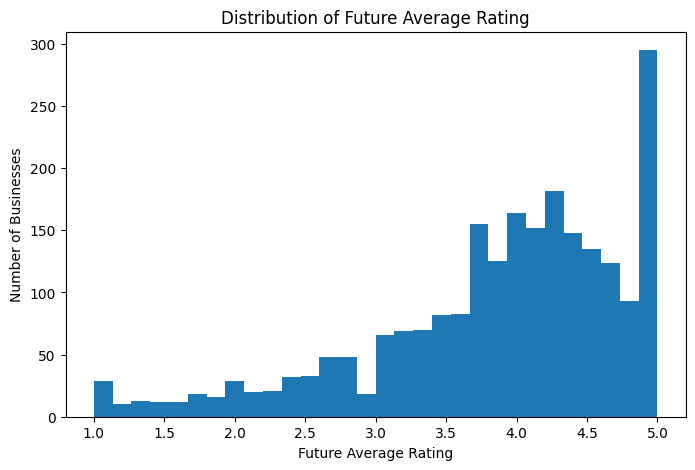

In [26]:
# Distribution of the target: future average rating
plt.figure(figsize=(8, 5))
plt.hist(model_df["future_avg_rating"], bins=30)
plt.xlabel("Future Average Rating")
plt.ylabel("Number of Businesses")
plt.title("Distribution of Future Average Rating")
plt.show()

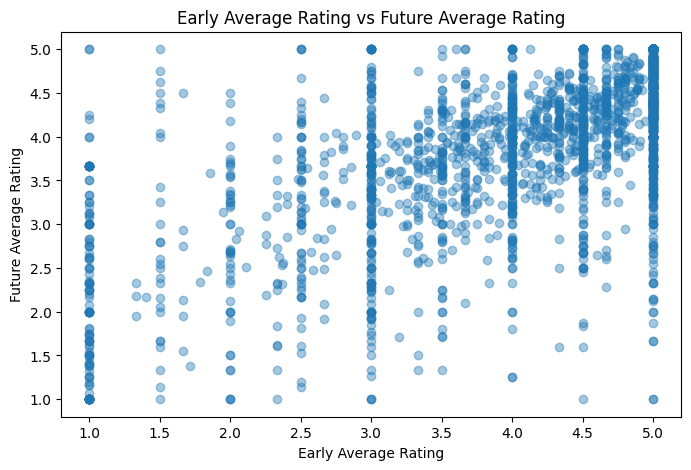

In [27]:
# Relationship between the main predictor and the target
plt.figure(figsize=(8, 5))
plt.scatter(model_df["early_avg_rating"], model_df["future_avg_rating"], alpha=0.4)
plt.xlabel("Early Average Rating")
plt.ylabel("Future Average Rating")
plt.title("Early Average Rating vs Future Average Rating")
plt.show()

In [28]:
# Correlations among the numeric variables
corr = model_df[[
    "early_review_count",
    "early_avg_rating",
    "early_rating_std",
    "early_avg_review_length",
    "future_review_count",
    "future_avg_rating",
    "future_avg_review_length"
]].corr()

print(corr["future_avg_rating"].sort_values(ascending=False))

future_avg_rating           1.000000
early_avg_rating            0.648733
future_review_count         0.104530
early_review_count          0.039057
early_avg_review_length    -0.126358
early_rating_std           -0.260296
future_avg_review_length   -0.268144
Name: future_avg_rating, dtype: float64


In [29]:
# Diagnostics: how many businesses survive each stage?
print("Businesses with early features:", early_features_df.shape[0])
print("Businesses with future target:", future_target_df.shape[0])
print(
    "Businesses after merge:",
    early_features_df.merge(future_target_df, on="business_id", how="inner").shape[0]
)
print("Businesses after min-review filters:", model_df.shape[0])

Businesses with early features: 11643
Businesses with future target: 10584
Businesses after merge: 10584
Businesses after min-review filters: 2302


## 8. Train/test split and baseline

We use a random 80/20 train/test split.

The baseline model predicts the **mean future rating in the training set** for every test business.
This gives us a simple reference point.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
import numpy as np

# Features used in the main model
feature_cols = [
    "early_review_count",
    "early_avg_rating",
    "early_rating_std",
    "early_avg_review_length"
]

X = model_df[feature_cols]
y = model_df["future_avg_rating"]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1841, 4)
X_test shape: (461, 4)
y_train shape: (1841,)
y_test shape: (461,)


In [31]:
# Baseline: always predict the training-set mean
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline results")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R^2:", baseline_r2)

Baseline results
MAE: 0.672114031919065
RMSE: 0.856682279006033
R^2: -0.017417009310595644


## 9. Linear regression

This is the main predictive model. It estimates a linear relationship between the early business features and the future average rating.


In [32]:
# Fit the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
lr_pred = lr_model.predict(X_test)

# Evaluate performance
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Adjusted R^2
n = len(y_test)        # number of test observations
p = X_test.shape[1]    # number of predictors

lr_adj_r2 = 1 - (1 - lr_r2) * (n - 1) / (n - p - 1)

print("Linear Regression results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R^2:", lr_r2)
print("Adjusted R^2:", lr_adj_r2)

Linear Regression results
MAE: 0.48848598310687735
RMSE: 0.6791964495176911
R^2: 0.36048572776059873
Adjusted R^2: 0.35487595344270917


/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [33]:
# Display the linear regression coefficients
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
1,early_avg_rating,0.546103
0,early_review_count,0.004712
3,early_avg_review_length,0.000558
2,early_rating_std,-0.016446


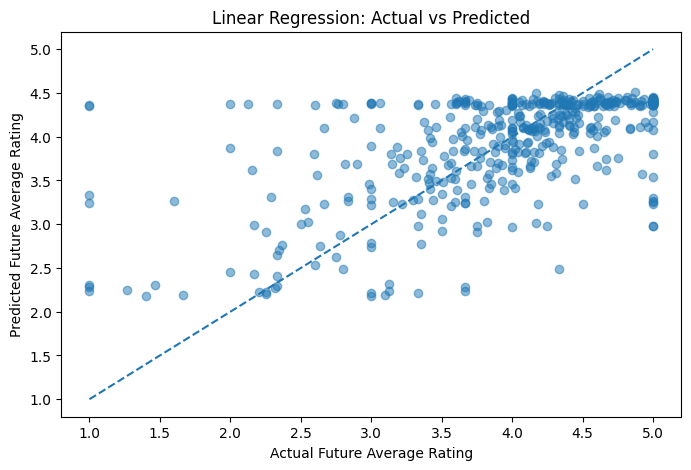

In [34]:
# Predicted vs actual values for linear regression
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_pred, alpha=0.5)

# Add the diagonal line for perfect predictions
min_val = min(y_test.min(), lr_pred.min())
max_val = max(y_test.max(), lr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Future Average Rating")
plt.ylabel("Predicted Future Average Rating")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

## 10. Ridge regression

Ridge regression is a regularized version of linear regression.
It is useful as a comparison model to check whether mild regularization improves performance.


In [35]:
# Fit the ridge regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predict on the test set
ridge_pred = ridge_model.predict(X_test)

# Evaluate performance
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

# Adjusted R^2
n = len(y_test)        # number of test observations
p = X_test.shape[1]    # number of predictors

ridge_adj_r2 = 1 - (1 - ridge_r2) * (n - 1) / (n - p - 1)

print("Ridge Regression results")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R^2:", ridge_r2)
print("Adjusted R^2:", ridge_adj_r2)

Ridge Regression results
MAE: 0.4884899624297938
RMSE: 0.6791827726502367
R^2: 0.36051148308920467
Adjusted R^2: 0.35490193469525033


/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [36]:
# Display the ridge regression coefficients
ridge_coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": ridge_model.coef_
}).sort_values("coefficient", ascending=False)

ridge_coef_df

,feature,coefficient
1,early_avg_rating,0.545816
0,early_review_count,0.004716
3,early_avg_review_length,0.000557
2,early_rating_std,-0.016589


## 11. Ablation study

The goal here is to see how much predictive signal comes from:

- **Model A**: only `early_avg_rating`
- **Model B**: rating-based features
- **Model C**: all current features

This helps show whether the extra features meaningfully improve performance.


In [37]:
# Reuse the same train/test indices for fair model comparison
train_idx = X_train.index
test_idx = X_test.index

feature_sets = {
    "Model A: early_avg_rating only": ["early_avg_rating"],
    "Model B: rating features": ["early_review_count", "early_avg_rating", "early_rating_std"],
    "Model C: all current features": ["early_review_count", "early_avg_rating", "early_rating_std", "early_avg_review_length"]
}

results = []

for model_name, cols in feature_sets.items():
    X_train_sub = model_df.loc[train_idx, cols]
    X_test_sub = model_df.loc[test_idx, cols]
    y_train_sub = model_df.loc[train_idx, "future_avg_rating"]
    y_test_sub = model_df.loc[test_idx, "future_avg_rating"]

    model = LinearRegression()
    model.fit(X_train_sub, y_train_sub)
    pred = model.predict(X_test_sub)

    mae = mean_absolute_error(y_test_sub, pred)
    rmse = np.sqrt(mean_squared_error(y_test_sub, pred))
    r2 = r2_score(y_test_sub, pred)

    results.append({
        "model": model_name,
        "features": ", ".join(cols),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-p

,model,features,MAE,RMSE,R2
0,Model A: early_avg_rating only,early_avg_rating,0.487817,0.678288,0.362194
2,Model C: all current features,"early_review_count, early_avg_rating, early_ra...",0.488486,0.679196,0.360486
1,Model B: rating features,"early_review_count, early_avg_rating, early_ra...",0.487641,0.679476,0.359959


# CATEGORIES

In [38]:
def map_broad_category(cat_string):
    if pd.isna(cat_string):
        return "Other"

    cat_string = cat_string.lower()

    if any(x in cat_string for x in [
        "restaurant", "food", "coffee", "tea", "bar", "bakery", "dessert",
        "pizza", "burgers", "sandwiches", "sushi", "mexican", "italian",
        "fast food", "cafes", "breakfast", "brunch", "ice cream",
        "juice bars", "smoothies", "seafood", "steakhouses", "donuts"
    ]):
        return "Food & Drink"

    elif any(x in cat_string for x in [
        "health", "medical", "dentist", "dentistry", "doctor", "doctors",
        "hospital", "pharmacy", "urgent care", "pain management",
        "diagnostic", "physical therapy", "massage therapy", "chiropractors",
        "nutritionists", "medical centers", "dermatologists", "optometrists"
    ]):
        return "Health & Medical"

    elif any(x in cat_string for x in [
        "shopping", "fashion", "department stores", "jewelry", "shoe stores",
        "women's clothing", "men's clothing", "home decor", "furniture stores",
        "electronics", "gift shops", "bookstores", "toy stores", "florists"
    ]):
        return "Shopping & Retail"

    elif any(x in cat_string for x in [
        "beauty", "spas", "hair salons", "nail salons", "waxing",
        "skin care", "barbers", "eyelash service", "makeup artists",
        "hair removal", "tattoo", "piercing"
    ]):
        return "Beauty & Personal Care"

    elif any(x in cat_string for x in [
        "automotive", "auto repair", "car dealers", "gas stations",
        "oil change", "car wash", "body shops", "auto parts", "tires",
        "towing", "car rental"
    ]):
        return "Automotive"

    elif any(x in cat_string for x in [
        "home services", "contractors", "plumbing", "electricians",
        "landscaping", "roofing", "flooring", "carpet cleaning",
        "home cleaning", "masonry", "painters", "hvac", "window washing"
    ]):
        return "Home Services"

    elif any(x in cat_string for x in [
        "professional services", "lawyers", "legal services", "accountants",
        "insurance", "marketing", "web design", "it services",
        "financial services", "business consulting", "employment agencies"
    ]):
        return "Professional Services"

    elif any(x in cat_string for x in [
        "arts", "entertainment", "museums", "performing arts",
        "music venues", "cinema", "festivals", "arcades", "paintball",
        "escape games", "art galleries"
    ]):
        return "Arts & Entertainment"

    elif any(x in cat_string for x in [
        "active life", "gyms", "fitness", "trainers", "yoga",
        "martial arts", "golf", "hiking", "swimming", "bike rentals",
        "trampoline parks", "sports clubs"
    ]):
        return "Active Life"

    elif any(x in cat_string for x in [
        "pets", "pet services", "pet groomers", "pet sitting",
        "veterinarians", "pet stores", "dog parks", "pet boarding"
    ]):
        return "Pets"

    elif any(x in cat_string for x in [
        "hotels", "travel", "hotels & travel", "airport shuttles",
        "tours", "vacation rentals", "resorts", "hostels", "bed & breakfast"
    ]):
        return "Hotels & Travel"

    elif any(x in cat_string for x in [
        "education", "schools", "colleges", "universities",
        "specialty schools", "preschools", "child care", "tutoring"
    ]):
        return "Education"

    elif any(x in cat_string for x in [
        "real estate", "property management", "apartments",
        "real estate agents", "real estate services"
    ]):
        return "Real Estate"

    elif any(x in cat_string for x in [
        "nightlife", "bars", "pubs", "cocktail bars", "wine bars",
        "lounges", "dance clubs", "hookah bars", "beer bar"
    ]):
        return "Nightlife"

    else:
        return "Other"

business_df["broad_category"] = business_df["categories"].apply(map_broad_category)

print(business_df["broad_category"].value_counts())

broad_category
Food & Drink              48470
Shopping & Retail         15507
Health & Medical          10568
Home Services             10020
Automotive                 9160
Beauty & Personal Care     7340
Other                      4706
Active Life                3432
Hotels & Travel            2901
Pets                       2867
Arts & Entertainment       2130
Professional Services      1940
Education                   567
Nightlife                    90
Name: count, dtype: int64


Merge the category into model_df

In [42]:
model_df = model_df.merge(
    business_df[["business_id", "broad_category"]],
    on="business_id",
    how="left"
)

print(model_df.columns.tolist())
print(model_df["broad_category"].value_counts())

['business_id', 'early_review_count', 'early_avg_rating', 'early_rating_std', 'early_avg_review_length', 'future_review_count', 'future_avg_rating', 'future_avg_review_length', 'broad_category']
broad_category
Food & Drink              1359
Shopping & Retail          176
Beauty & Personal Care     153
Home Services              137
Health & Medical           126
Automotive                  87
Active Life                 68
Arts & Entertainment        48
Hotels & Travel             45
Pets                        42
Other                       40
Professional Services       17
Education                    3
Nightlife                    1
Name: count, dtype: int64


Make a summary table by category

In [43]:
category_summary = (
    model_df.groupby("broad_category")
    .agg(
        n_businesses=("business_id", "count"),
        mean_early_rating=("early_avg_rating", "mean"),
        mean_future_rating=("future_avg_rating", "mean"),
        mean_early_review_length=("early_avg_review_length", "mean"),
        mean_future_review_length=("future_avg_review_length", "mean")
    )
    .sort_values("n_businesses", ascending=False)
)

print(category_summary)

                        n_businesses  mean_early_rating  mean_future_rating  \
broad_category                                                                
Food & Drink                    1359           4.012089            3.861694   
Shopping & Retail                176           4.093954            3.947897   
Beauty & Personal Care           153           4.343568            3.985214   
Home Services                    137           3.592944            3.584961   
Health & Medical                 126           3.965608            3.976987   
Automotive                        87           3.502874            3.562291   
Active Life                       68           4.338235            4.194048   
Arts & Entertainment              48           4.099502            4.165540   
Hotels & Travel                   45           3.335873            3.185424   
Pets                              42           4.314286            4.322678   
Other                             40           3.960

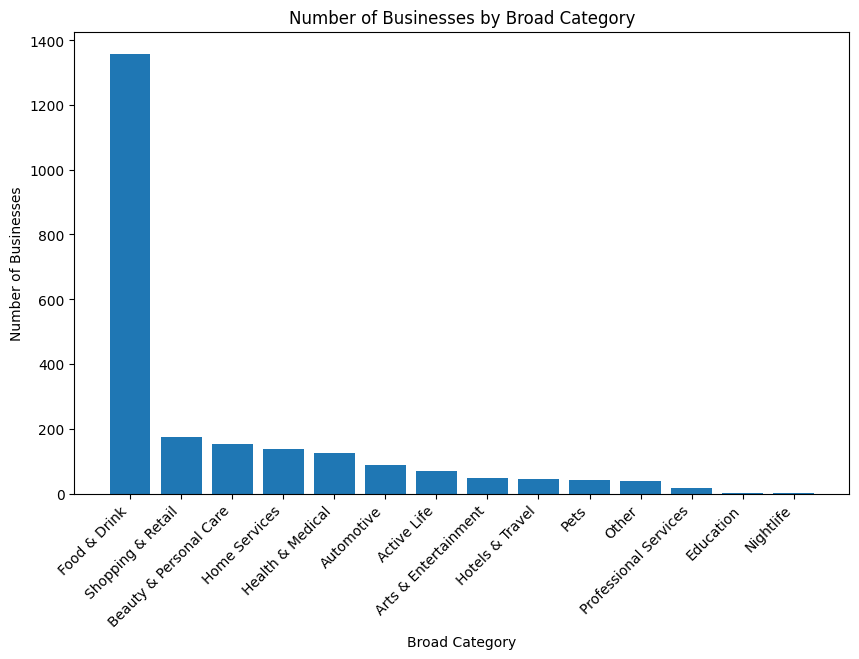

In [44]:
import matplotlib.pyplot as plt

plot_df = category_summary.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(plot_df["broad_category"], plot_df["n_businesses"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Broad Category")
plt.ylabel("Number of Businesses")
plt.title("Number of Businesses by Broad Category")
plt.show()

# Pearson correlation between early_avg_rating and future_avg_rating separately inside each broad category.

* close to 1 → strong positive relationship
* close to 0 → weak or no linear relationship
* close to -1 → strong negative relationship

In [45]:
category_corrs = (
    model_df.groupby("broad_category")
    .apply(lambda df: df["early_avg_rating"].corr(df["future_avg_rating"]))
    .reset_index(name="corr_early_future_rating")
    .sort_values("corr_early_future_rating", ascending=False)
)

print(category_corrs)

            broad_category  corr_early_future_rating
4                Education                  0.977356
12   Professional Services                  0.904119
10                   Other                  0.770170
8          Hotels & Travel                  0.734102
7            Home Services                  0.673022
0              Active Life                  0.667379
6         Health & Medical                  0.651337
5             Food & Drink                  0.630590
1     Arts & Entertainment                  0.625593
2               Automotive                  0.607141
13       Shopping & Retail                  0.599247
11                    Pets                  0.555160
3   Beauty & Personal Care                  0.515284
9                Nightlife                       NaN


/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/julianaelrayes/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/var/folders/zh/qnyy37jx7l142313hpl58gp80000gn/T/ipykernel_22437/2888132512.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_

# overall comparison about review lenght

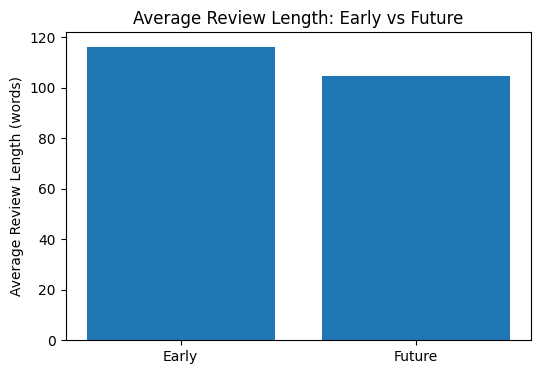

early_avg_review_length     116.068597
future_avg_review_length    104.443975
dtype: float64


In [46]:
import matplotlib.pyplot as plt

length_means = model_df[["early_avg_review_length", "future_avg_review_length"]].mean()

plt.figure(figsize=(6, 4))
plt.bar(["Early", "Future"], length_means.values)
plt.ylabel("Average Review Length (words)")
plt.title("Average Review Length: Early vs Future")
plt.show()

print(length_means)

## 12. Interpretation and takeaway

1. The baseline model, which predicts the mean future rating for every business, performed much worse than the regression models. The baseline had an MAE of about 0.730, an RMSE of about 0.953, and an R^2 slightly below zero, while linear regression reduced the error substantially and achieved an R^2 of about 0.504. This means the early review features contain real predictive signal and are not just matching what a naive average would do.

2. Linear regression performed clearly better than the baseline, with an MAE of about 0.494, an RMSE of about 0.662, and an R^2 of about 0.504. Ridge regression produced almost identical results, which suggests the feature set is already fairly stable and that regularization does not change the overall conclusion much. In other words, the relationship between early review behavior and later rating is strong enough to be captured well even by a simple linear model.

3. Early average rating is doing most of the work. The model using only early average rating already achieved an R^2 of about 0.502. Adding early review count and early rating standard deviation increased performance only slightly, and adding average review length improved it by almost nothing. This suggests that a business’s average rating in its first 30 days is already the dominant signal for predicting its average rating over the rest of its first year.

**A business’s average rating in its first 30 days is already a strong predictor of its average rating over the rest of its first year.**